In [1]:
import os

In [2]:
os.getcwd()

'C:\\python'

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11843
           1       1.00      0.99      0.99      3891

    accuracy                           1.00     15734
   macro avg       1.00      0.99      0.99     15734
weighted avg       1.00      1.00      1.00     15734

Confusion Matrix:
 [[11828    15]
 [   50  3841]]
Accuracy Score: 0.995868819117834


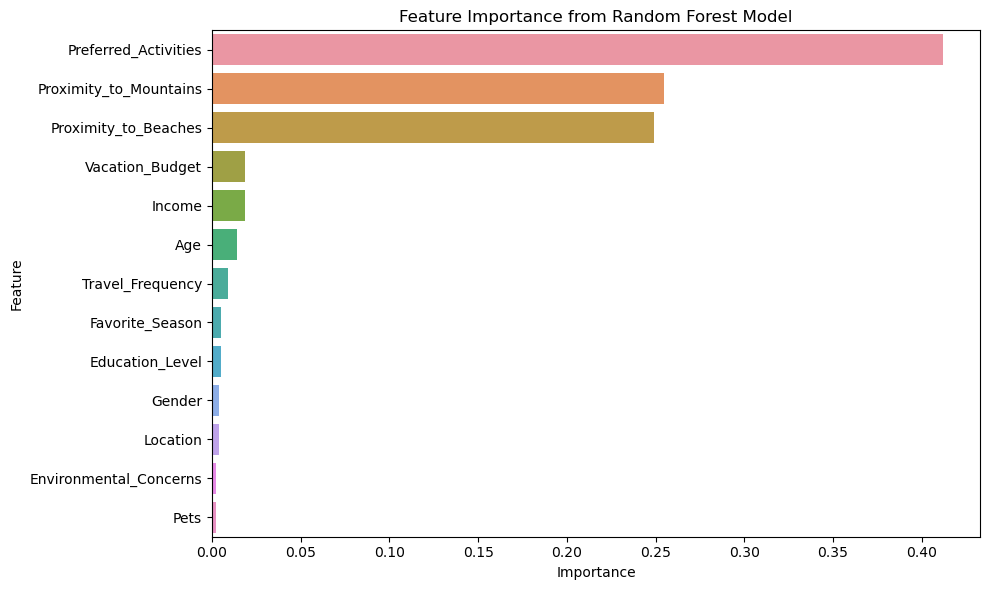

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('mountains_vs_beaches_preferences.csv')

# Encode categorical variables
label_encoders = {}
categorical_columns = ['Gender', 'Education_Level', 'Preferred_Activities', 'Location', 'Favorite_Season']

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Define features and target variable
X = df.drop(columns=['Preference'])
y = df['Preference']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Generate classification report, confusion matrix, and accuracy score
classification_rep = classification_report(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Display results
print("Classification Report:\n", classification_rep)
print("Confusion Matrix:\n", confusion_mat)
print("Accuracy Score:", accuracy)

# Feature importance visualization
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [7]:
df

,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,1,71477,0,9,1,2477,2,175,267,2,0,1,1
1,69,1,88740,3,1,3,4777,1,228,190,0,0,1,0
2,46,0,46562,3,0,1,1469,2,71,280,3,0,0,1
3,32,2,99044,2,6,0,1482,0,31,255,2,1,0,1
4,60,0,106583,2,5,2,516,1,23,151,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52439,67,0,85325,3,3,0,1762,1,51,262,0,1,0,1
52440,37,0,110346,0,7,3,1676,2,259,84,1,1,0,0
52441,53,2,71080,1,7,3,3877,2,164,27,0,0,1,0
52442,40,0,75174,1,9,3,4620,1,173,10,2,0,1,0


In [8]:
df.columns

Index(['Age', 'Gender', 'Income', 'Education_Level', 'Travel_Frequency',
       'Preferred_Activities', 'Vacation_Budget', 'Location',
       'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Favorite_Season',
       'Pets', 'Environmental_Concerns', 'Preference'],
      dtype='object')

In [ ]:
Index(['Age', 'Gender', 'Income', 'Education_Level', 'Travel_Frequency',
       'Preferred_Activities', 'Vacation_Budget', 'Location',
       'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Favorite_Season',
       'Pets', 'Environmental_Concerns', 'Preference'],
      dtype='object')

In [12]:
df2 = [df['Preferred_Activities'],df['Preference']]

In [13]:
df2

[0        1
 1        3
 2        1
 3        0
 4        2
         ..
 52439    0
 52440    3
 52441    3
 52442    3
 52443    0
 Name: Preferred_Activities, Length: 52444, dtype: int32,
 0        1
 1        0
 2        1
 3        1
 4        0
         ..
 52439    1
 52440    0
 52441    0
 52442    0
 52443    0
 Name: Preference, Length: 52444, dtype: int64]

AttributeError: 'numpy.int64' object has no attribute 'startswith'

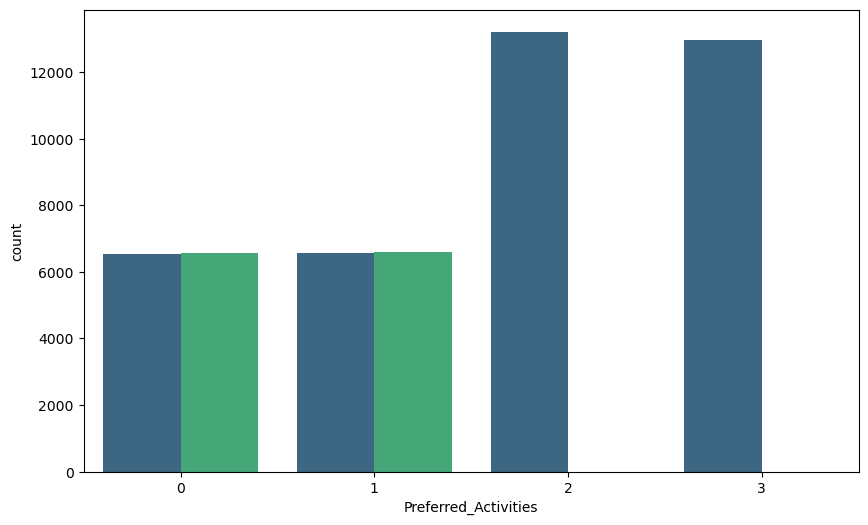

In [14]:
# Create a new DataFrame with Preferred Activities and Preference
df2 = df[['Preferred_Activities', 'Preference']]

# Plotting the count of mountain and beach preferences for each activity
plt.figure(figsize=(10, 6))
sns.countplot(data=df2, x='Preferred_Activities', hue='Preference', palette='viridis')
plt.title('Preference Count by Preferred Activities')
plt.xlabel('Preferred Activities')
plt.ylabel('Count')
plt.legend(title='Preference', labels=['Beach', 'Mountain'])
plt.tight_layout()
plt.show()
